## LLM-enhanced Linux Kernel Profiling/Enhancement

In [54]:
%load_ext autoreload
%autoreload 2
import networkx as nx
import matplotlib.pyplot as plt
import os
import scipy
from kfunc_filter import should_filter_function

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First of all, we have to load the static kernel call graph.

In [55]:
kernel_cg_path = "./callgraph.graphml"
k_cg = nx.read_graphml(kernel_cg_path)

# prune self-loops
k_cg.remove_edges_from(nx.selfloop_edges(k_cg))

In this CallGraph (CG), each node is a *function name*, and each edge (u, v) denotes a *call relation* u (caller) -> v (callee).

For a single node u1, it may has different call targets (let's say {v1, v2, ..., vn}).

- If function u1 has indirect calls (u1 as the callsite), then it will has `u1.has_indirect = True`.
- If function u1 has indirect call targets, for each edge {(u1, v1), (u1, v2), ...}, the indirect call edge will have property `indirect = True`

See the demonstrated `describe_node` below.

In [56]:
def describe_node(graph, node):
    if node not in graph:
        print(f"Node {node} does not exist in the graph.")
        return

    print(f"Node: {node}")
    print(f"Has indirect calls: {graph.nodes[node].get('has_indirect', False)}")

    print("Outgoing edges:")
    for _, target, edge_data in graph.out_edges(node, data=True):
        indirect = edge_data.get('indirect', False)
        print(f"  {node} -> {target:<20} (is indirect call: {indirect})")

Read this kernel function (`filp_close`) source code:
```c
int filp_close(struct file *filp, fl_owner_t id)
{
	int retval = 0;

	if (!file_count(filp)) {
		printk(KERN_ERR "VFS: Close: file count is 0\n");
		return 0;
	}

	if (filp->f_op->flush)
		retval = filp->f_op->flush(filp, id);

	if (likely(!(filp->f_mode & FMODE_PATH))) {
		dnotify_flush(filp, id);
		locks_remove_posix(filp, id);
	}
	fput(filp);
	return retval;
}
```

From the source code, you can see it has several direct calls:
```
filp_close -> printk
filp_close -> dnotify_flush
filp_close -> locks_remove_posix
filp_close -> fput
```

And it has indirect call: `filp_close -> filp->f_op->flush()`.

In [57]:
# This u1 ("filp_close") is a node with indirect calls
describe_node(k_cg, "filp_close")

Node: filp_close
Has indirect calls: True
Outgoing edges:
  filp_close -> _printk              (is indirect call: False)
  filp_close -> dnotify_flush        (is indirect call: False)
  filp_close -> fput                 (is indirect call: False)
  filp_close -> locks_remove_posix   (is indirect call: False)
  filp_close -> mqueue_flush_file    (is indirect call: True)
  filp_close -> nfs4_file_flush      (is indirect call: True)
  filp_close -> nfs_file_flush       (is indirect call: True)


In [58]:
# This u2 ("__x64_sys_close") is a node without indirect calls. 
# This is the entry function of a syscall `close`.
describe_node(k_cg, "__x64_sys_close")

Node: __x64_sys_close
Has indirect calls: False
Outgoing edges:
  __x64_sys_close -> close_fd             (is indirect call: False)


### 1. Ask LLM to generate per-function summary

LLMs have been proven to show good performance of understanding code semantics and summarizing the behavior of functions [1-3].
> [1] Large Language Models for Code Analysis: Do LLMs Really Do Their Job? (Usenix Security'24)
>
> [2] kernelGPT: Enhanced Kernel Fuzzing via Large Language Models (ASPLOS'25)
>
> [3] Exploiting Code Symmetries for Learning Program Semantics (arxiv)

In this work, we would use Qwen3-32B (https://huggingface.co/Qwen/Qwen3-32B) (or any other state-of-the-art code LLM).


For every individual function, we need to request LLM to summarize its semantics, include the function definitions and behaviors.

**Input**: function source code (e.g., the above `filp_close` source code).

**Output**: function prototype and code semantics summary.

Here is demonstrated prompts:

**Prompt0**:
I will input Linux kernel function source code. Please read the source code and summarize its behavior.
My input: function definition and source code.
Your output:
```
{
   "func_name": input function, 
   "prototype": its argument types and return value types,
   "summary": its behavior (within X words),
}.
```
**Prompt1:** filp_close

**Answer1:** 
```
{
   "func_name": "filp_close",
   "prototype": "args: {struct file *, fl_owner_t}, ret: {int}",
   "summary": "Closes a file descriptor by performing flush operations, removing file notifications, releasing POSIX locks, and decrementing the file reference count. Returns the result of the flush operation if implemented."
}
```

In [59]:
# Here are all kernel functions in the call graph
# You only need to consider functions that are not filtered out
# (we filter functions if they are related to interrupt handlers/context switches)

kall_functions = [node for node in k_cg.nodes if not should_filter_function(node)]
print(f"Total kernel functions (after filtering): {len(kall_functions)}/{len(k_cg.nodes)}")

Total kernel functions (after filtering): 41881/45596


### 2. Ask LLM to enhance our dynamic profile

A dynamic profile contains all performs benign behaviors (of a syscall) during our certain workloads. It would absolutely under-approximate the potential behaviors of that syscall.

We will input the dynamic profile into LLM to let it enlarge possible benign behaviors, by analyzing the code semantics and contexts.

In [71]:
def gen_callgraph(graph, sys_entry_function, function_set):
    """
    Generate a dynamic call graph for a given function.
    """
    # filter out nodes in should_filter_function before intersection
    reachable_nodes = nx.descendants(graph, sys_entry_function).intersection(function_set)
    reachable_nodes.add(sys_entry_function)  # Include the entry function itself
    
    subgraph = graph.subgraph(reachable_nodes).copy()  # Create a copy to preserve attributes
    
    # Iteratively remove nodes with no in-degrees except for the sys_entry_function
    nodes_to_remove = [node for node in subgraph if subgraph.in_degree(node) == 0 and node != sys_entry_function]
    while nodes_to_remove:
        subgraph.remove_nodes_from(nodes_to_remove)
        # print(f"Removed nodes: {nodes_to_remove}")
        nodes_to_remove = [node for node in subgraph if subgraph.in_degree(node) == 0 and node != sys_entry_function]
    
    return subgraph

In [61]:
def draw_subgraph(graph, graph_name):
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(graph)  # Use the graph layout
    in_degree_zero_nodes = [node for node in graph if graph.in_degree(node) == 0]
    node_colors = ['red' if node in in_degree_zero_nodes else 'lightblue' for node in graph.nodes]
    nx.draw(graph, pos, with_labels=True, node_size=500, font_size=10, node_color=node_colors, edge_color='black')
    print(f"Subgraph number of nodes: {len(graph.nodes())}, number of edges: {len(graph.edges())}")
    plt.title(f"Subgraph: {graph_name}")
    plt.show()


Now, we will draw a purely dynamic graph (starting from `__x64_sys_close`, by using the profile of `close` syscall).

Subgraph number of nodes: 6, number of edges: 5


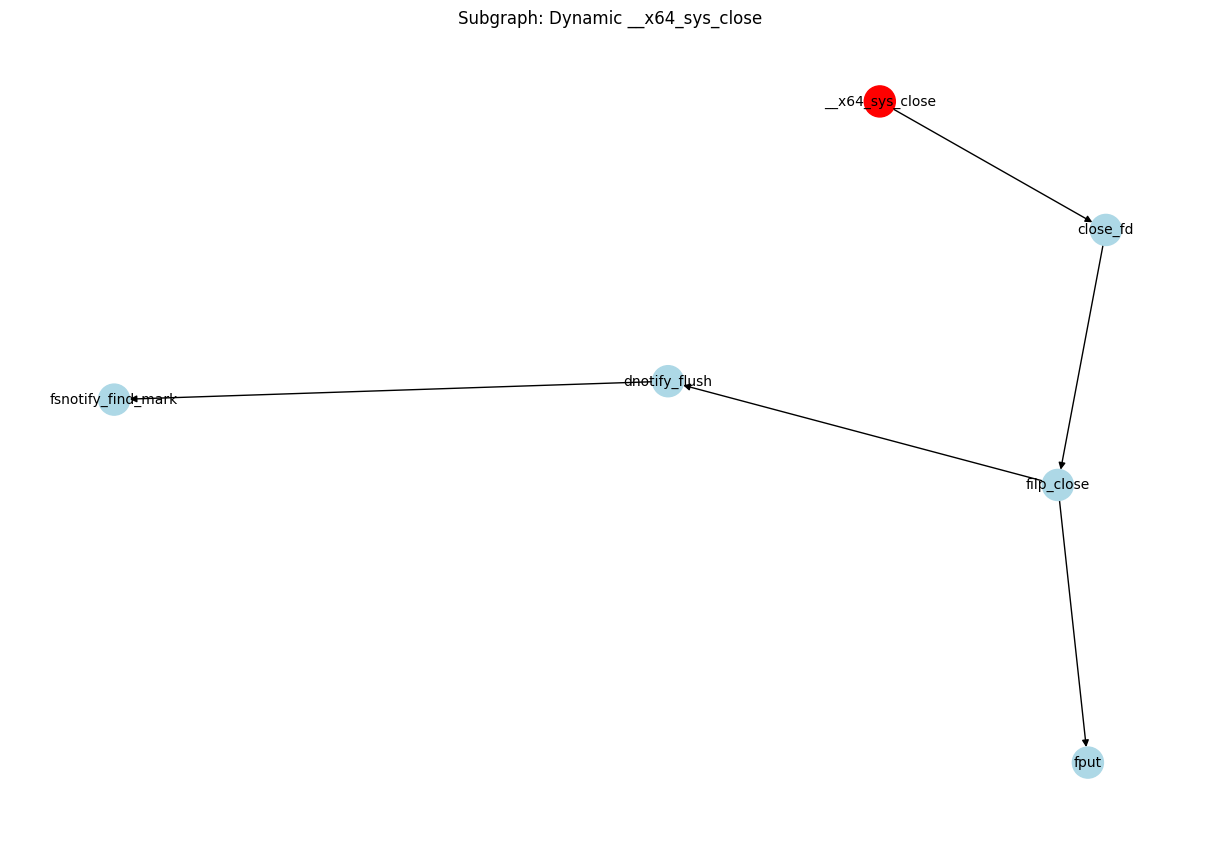

In [73]:
# Let's play with a demo profile for now
demo_profile = "./demo-profile-sysclose.txt"

# extract all functions in that profiles
demo_profiled_functions = set()

with open(demo_profile, "r") as f:
    lines = f.readlines()
    for line in lines:
        func_name = line.strip()
        if func_name in kall_functions and not should_filter_function(func_name):
            demo_profiled_functions.add(func_name)
    
# generate the dynamic call graph as its contextual information
# Extract the subgraph containing only the demo_profiled_functions
subgraph = gen_callgraph(k_cg, "__x64_sys_close", demo_profiled_functions)

# Draw the subgraph
draw_subgraph(subgraph, "Dynamic __x64_sys_close")

Now, we will also see the statistics of the static callgraph of `close` syscall (starting from `__x64_sys_close`).

In [63]:
static_subgraph = gen_callgraph(k_cg, "__x64_sys_close", kall_functions)

print(f"Static subgraph number of nodes: {len(static_subgraph.nodes())}, number of edges: {len(static_subgraph.edges())}")


Removed nodes: ['ext4_unfreeze', 'print_daily_error_info', '__ext4_forget', 'ext4_mark_bitmap_end', 'ext4_fc_replay_check_excluded', 'ext4_split_extent', 'ext4_da_update_reserve_space', 'ext4_es_delayed_clu', 'get_implied_cluster_alloc', 'ext4_sb_setuuid', 'ext4_sb_setlabel', 'ext4_list_backups', 'set_overhead', 'ext4_mb_free_metadata', 'ext4_mb_discard_group_preallocations', 'ext4_mb_release_context', 'ext4_mb_mark_diskspace_used', 'ext4_mb_regular_allocator', 'ext4_mb_normalize_request', 'ext4_mb_use_preallocated', 'ext4_mb_initialize_context', 'ext4_group_desc_csum_verify', 'ext4_es_scan_clu', 'ext4_es_scan_range', 'ext4_init_dot_dotdot', 'ext4_initialize_dirent_tail', 'ext4_da_reserve_space', 'ext4_clu_mapped', 'ext4_es_lookup_extent', 'jbd2_journal_inode_ranged_wait', 'ext4_check_all_de', 'nlm_async_call', 'nlmclnt_next_cookie', 'svc_find_xprt', 'svc_age_temp_xprts_now', 'nlmsvc_get_owner', 'nsm_unmonitor', 'security_task_getscheduler', 'kstrtoull_from_user', 'nlmclnt_proc', 'do_s

In [68]:
"_raw_spin_lock" in kall_functions

False

In [70]:
describe_node(k_cg, "mqueue_flush_file")

Node: mqueue_flush_file
Has indirect calls: False
Outgoing edges:
  mqueue_flush_file -> _raw_spin_lock       (is indirect call: False)
  mqueue_flush_file -> _raw_spin_unlock     (is indirect call: False)
  mqueue_flush_file -> netlink_sendskb      (is indirect call: False)
  mqueue_flush_file -> put_pid              (is indirect call: False)
